# AUV v0.3 — pierwsza implementacja koncepcji 'kosztu cywilizacji'

Pierwsza działająca wersja AUV oparta na formule

$$\text{realna\_wartość}_i(t) = p_i(t) \cdot \frac{N(t)}{q_i(t)}$$

gdzie:
- $p_i$ — cena zasobu (w USD)
- $N(t)$ — populacja świata
- $q_i(t)$ — globalna roczna produkcja

Wersja v0.3.0 obejmuje *dwie kategorie* (z planowanych pięciu):

1. **Żywność** — średnia cena głównych zbóż (pszenica, kukurydza, soja, ryż) ÷ produkcja zbóż na świecie ze World Bank.
2. **Energia** — średnia cena (ropa Brent, gaz Henry Hub, węgiel australijski), z proxy produkcji opartym na zużyciu energii per capita × populacja.

Brakuje kategorii **metale** (potrzebny USGS), **materiały budowlane** (cement, stal — wymaga osobnych źródeł) i **materiały krytyczne** (lit, kobalt, ziemie rzadkie). Te zostaną dodane w v0.3.1.

In [6]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)

PROTOTYP_ROOT = Path.cwd().parent
if str(PROTOTYP_ROOT) not in sys.path:
    sys.path.insert(0, str(PROTOTYP_ROOT))

from src.auv_v3 import construct_auv_v3

DATA_DIR = PROTOTYP_ROOT / 'data' / 'processed'
FIG_DIR = PROTOTYP_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR = PROTOTYP_ROOT / 'outputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

monthly = pd.read_parquet(DATA_DIR / 'monthly.parquet')
print(f'Loaded monthly: {monthly.shape}')

Loaded monthly: (360, 47)


## 1. Nowe dane — populacja i produkcja

Najpierw obejrzymy, co przynosi World Bank do projektu.

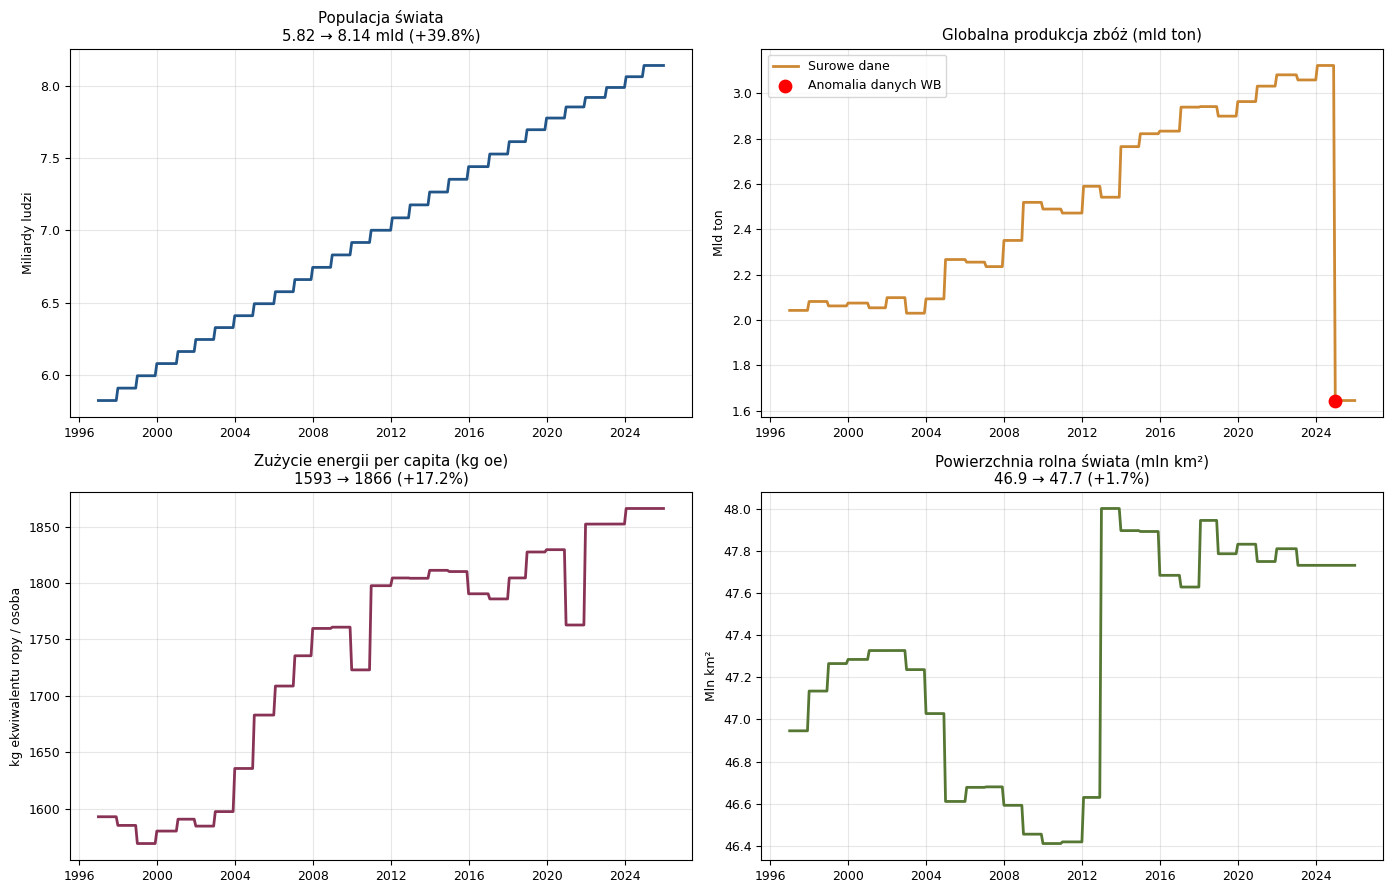

Populacja świata wzrosła o ~40% w 30 lat — to centralny mianownik formuły v0.3.
Produkcja zbóż wzrosła z ~2 do ~3 mld ton (+50%) — szybciej niż populacja!
Zużycie energii per capita wzrosło o 17% — cywilizacja jest energochłonniejsza.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
pop = monthly['world_population'].dropna()
ax.plot(pop.index, pop.values / 1e9, color='#225588', linewidth=2)
ax.set_title(f'Populacja świata\n{pop.iloc[0]/1e9:.2f} → {pop.iloc[-1]/1e9:.2f} mld ({(pop.iloc[-1]/pop.iloc[0]-1)*100:+.1f}%)')
ax.set_ylabel('Miliardy ludzi')
ax.grid(alpha=0.3)

ax = axes[0, 1]
cereal = monthly['cereal_production_world'].dropna()
ax.plot(cereal.index, cereal.values / 1e9, color='#cc8833', linewidth=2, label='Surowe dane')
# Oznacz anomalię
anomaly_date = pd.Timestamp('2024-12-31')
if anomaly_date in cereal.index:
    ax.scatter([anomaly_date], [cereal.loc[anomaly_date]/1e9], color='red', s=80, zorder=5, label='Anomalia danych WB')
ax.set_title('Globalna produkcja zbóż (mld ton)')
ax.set_ylabel('Mld ton')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
energy = monthly['energy_use_per_capita'].dropna()
ax.plot(energy.index, energy.values, color='#883355', linewidth=2)
ax.set_title(f'Zużycie energii per capita (kg oe)\n{energy.iloc[0]:.0f} → {energy.iloc[-1]:.0f} ({(energy.iloc[-1]/energy.iloc[0]-1)*100:+.1f}%)')
ax.set_ylabel('kg ekwiwalentu ropy / osoba')
ax.grid(alpha=0.3)

ax = axes[1, 1]
ag_land = monthly['agricultural_land_world'].dropna()
ax.plot(ag_land.index, ag_land.values / 1e6, color='#557733', linewidth=2)
ax.set_title(f'Powierzchnia rolna świata (mln km²)\n{ag_land.iloc[0]/1e6:.1f} → {ag_land.iloc[-1]/1e6:.1f} ({(ag_land.iloc[-1]/ag_land.iloc[0]-1)*100:+.1f}%)')
ax.set_ylabel('Mln km²')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '11_v3_input_data.png', dpi=150, bbox_inches='tight')
plt.show()

print('Populacja świata wzrosła o ~40% w 30 lat — to centralny mianownik formuły v0.3.')
print('Produkcja zbóż wzrosła z ~2 do ~3 mld ton (+50%) — szybciej niż populacja!')
print('Zużycie energii per capita wzrosło o 17% — cywilizacja jest energochłonniejsza.')

## 2. Uruchomienie pipeline'u v0.3

Pełny pipeline z defensywnym oczyszczaniem anomalii.

In [8]:
result = construct_auv_v3(monthly, weights={'food': 0.50, 'energy': 0.50}, t0='2017-06-30')

print(f'AUV v0.3 — metadata:')
for k, v in result.metadata.items():
    print(f'  {k}: {v}')

print(f'\nNotatki z oczyszczania danych ({len(result.cleaning_notes)}):')
for note in result.cleaning_notes:
    print(f'  • {note}')

print(f'\nKluczowe punkty AUV v3:')
key_dates = {
    '1998-08-31': 'Russia default',
    '2000-12-31': 'Dotcom peak',
    '2008-09-30': 'Lehman',
    '2014-12-31': 'Oil collapse',
    '2017-06-30': 't_0 (=100)',
    '2020-03-31': 'COVID',
    '2022-02-28': 'Ukraine war',
    '2025-12-31': 'Aktualnie',
}
for date, label in key_dates.items():
    try:
        val = result.auv_series.loc[date]
        print(f'  {date} ({label:18s}): AUV = {val:6.1f}')
    except KeyError:
        pass

AUV v0.3 — metadata:
  t0: 2017-06-30
  weights: {'food': 0.5, 'energy': 0.5}
  version: 0.3.0
  scope: food + energy (proxy)
  limitations: Brak produkcji metali (potrzebny USGS), brak produkcji ropy/gazu (potrzebny EIA z kluczem), brak materiałów budowlanych. Wersja demonstracyjna do walidacji koncepcji.

Notatki z oczyszczania danych (1):
  • cereal_production_world @ 2024-12-31: anomalia (1,644,081,590 vs poprzednia 3,123,613,733) — zastąpiono carry-forward.

Kluczowe punkty AUV v3:
  1998-08-31 (Russia default    ): AUV =   20.1
  2000-12-31 (Dotcom peak       ): AUV =   76.6
  2008-09-30 (Lehman            ): AUV =  106.2
  2014-12-31 (Oil collapse      ): AUV =  110.8
  2017-06-30 (t_0 (=100)        ): AUV =  100.0
  2020-03-31 (COVID             ): AUV =   79.0
  2022-02-28 (Ukraine war       ): AUV =  196.5
  2025-12-31 (Aktualnie         ): AUV =  170.0


## 3. Realne wartości kategorii — co AUV się składa

Każda kategoria osobno, żeby zobaczyć, która dominuje ruch całego wskaźnika.

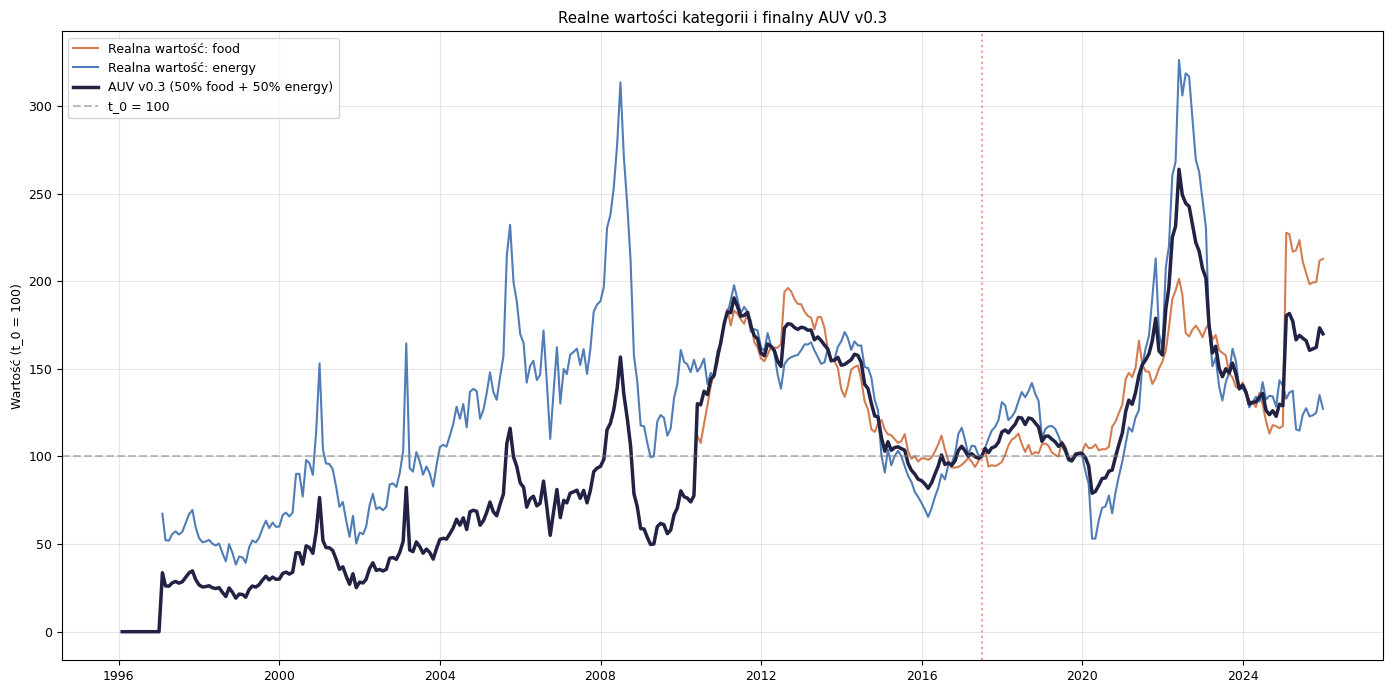

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

t0_ts = pd.Timestamp('2017-06-30')
realne = result.realne_wartosci.copy()

# Znormalizuj każdą kategorię do t_0=100
for col in realne.columns:
    s = realne[col].dropna()
    if t0_ts in s.index:
        realne[col] = realne[col] / s.loc[t0_ts] * 100

for col, color in [('food', '#cc6633'), ('energy', '#3366aa')]:
    if col in realne.columns:
        ax.plot(realne.index, realne[col], label=f'Realna wartość: {col}', color=color, linewidth=1.5, alpha=0.85)

auv = result.auv_series
ax.plot(auv.index, auv.values, label='AUV v0.3 (50% food + 50% energy)', color='#222244', linewidth=2.5)

ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='t_0 = 100')
ax.axvline(t0_ts, color='red', linestyle=':', alpha=0.4)
ax.set_title('Realne wartości kategorii i finalny AUV v0.3')
ax.set_ylabel('Wartość (t_0 = 100)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Anotuj kluczowe wydarzenia
for date, label in [('2008-09-01', 'Lehman'), ('2014-06-01', 'Oil'), ('2020-03-01', 'COVID'), ('2022-02-01', 'Ukraine')]:
    d = pd.Timestamp(date)
    if d in auv.index:
        ax.annotate(label, xy=(d, auv.loc[d]), xytext=(5, 15),
                    textcoords='offset points', fontsize=8,
                    arrowprops=dict(arrowstyle='->', alpha=0.4))

plt.tight_layout()
plt.savefig(FIG_DIR / '12_v3_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. AUV v0.3 vs AUV v0.2 vs M2_USA

Najważniejsze porównanie. Jak zachowuje się nowy AUV w stosunku do poprzedniej wersji i do ekspansji monetarnej?

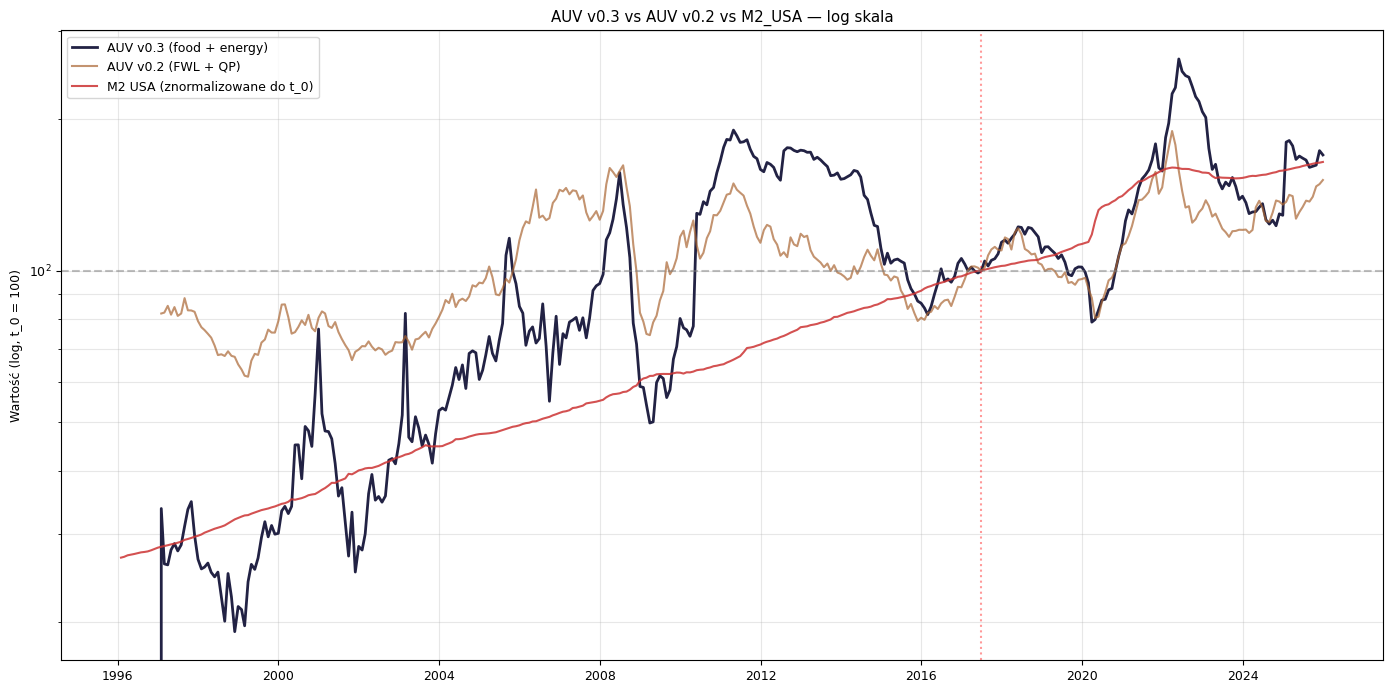

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

# AUV v0.3
ax.plot(auv.index, auv.values, label='AUV v0.3 (food + energy)', color='#222244', linewidth=2)

# AUV v0.2 — jeśli istnieje
auv_v2_path = OUTPUTS_DIR / 'auv_series.csv'
if auv_v2_path.exists():
    # Plik v0.2 ma indeks bez nazwy kolumny — czytamy index_col=0 i parsujemy daty osobno
    auv_v2 = pd.read_csv(auv_v2_path, index_col=0)['AUV']
    auv_v2.index = pd.to_datetime(auv_v2.index)
    auv_v2 = auv_v2.dropna()  # początek pliku ma NaN przed startem FWL
    # Znormalizuj v2 do tego samego t_0
    if t0_ts in auv_v2.index:
        auv_v2_norm = auv_v2 / auv_v2.loc[t0_ts] * 100
        ax.plot(auv_v2_norm.index, auv_v2_norm.values, label='AUV v0.2 (FWL + QP)', color='#aa6633', linewidth=1.5, alpha=0.7)

# M2 USA
m2 = monthly['M2_USA'].dropna()
m2_norm = m2 / m2.loc[m2.index[m2.index.get_indexer([t0_ts], method='nearest')[0]]] * 100
ax.plot(m2_norm.index, m2_norm.values, label='M2 USA (znormalizowane do t_0)', color='#cc3333', linewidth=1.5, alpha=0.85)

ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax.axvline(t0_ts, color='red', linestyle=':', alpha=0.4)
ax.set_yscale('log')
ax.set_title('AUV v0.3 vs AUV v0.2 vs M2_USA — log skala')
ax.set_ylabel('Wartość (log, t_0 = 100)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIG_DIR / '13_v3_vs_v2_vs_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ile USD i PLN za 1 AUV v0.3 w czasie

Najbardziej praktyczna interpretacja — realny spadek wartości walut wobec AUV.

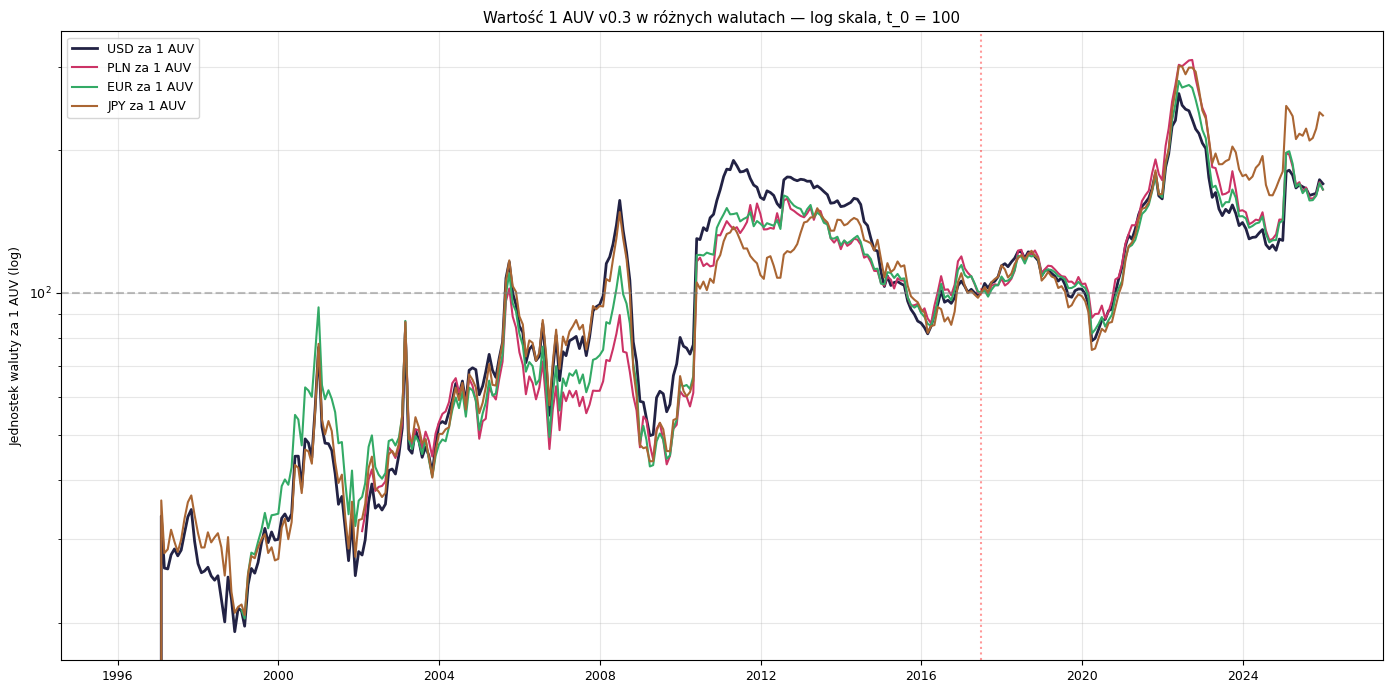


Realna deprecjacja walut wobec AUV v0.3 (t_0 = 2017-06 → 2025-12):
  USD:  +70.0%
  EUR:  +65.3%
  PLN:  +65.2%
  JPY: +137.1%
  GBP:  +64.3%
  BRL: +181.6%


In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# USD: sama wartość AUV w USD
ax.plot(auv.index, auv.values, label='USD za 1 AUV', color='#222244', linewidth=2)

# PLN: AUV * (PLN/USD)
if 'PLN' in monthly.columns:
    rate = monthly['PLN'].dropna()
    common = auv.index.intersection(rate.index)
    auv_pln = auv.loc[common] * rate.loc[common]
    if t0_ts in auv_pln.index:
        auv_pln_norm = auv_pln / auv_pln.loc[t0_ts] * 100
        ax.plot(auv_pln_norm.index, auv_pln_norm.values, label='PLN za 1 AUV', color='#cc3366', linewidth=1.5)

# EUR
if 'EUR' in monthly.columns:
    rate = monthly['EUR'].dropna()
    common = auv.index.intersection(rate.index)
    auv_eur = auv.loc[common] * rate.loc[common]
    if t0_ts in auv_eur.index:
        auv_eur_norm = auv_eur / auv_eur.loc[t0_ts] * 100
        ax.plot(auv_eur_norm.index, auv_eur_norm.values, label='EUR za 1 AUV', color='#33aa66', linewidth=1.5)

# JPY
if 'JPY' in monthly.columns:
    rate = monthly['JPY'].dropna()
    common = auv.index.intersection(rate.index)
    auv_jpy = auv.loc[common] * rate.loc[common]
    if t0_ts in auv_jpy.index:
        auv_jpy_norm = auv_jpy / auv_jpy.loc[t0_ts] * 100
        ax.plot(auv_jpy_norm.index, auv_jpy_norm.values, label='JPY za 1 AUV', color='#aa6633', linewidth=1.5)

ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax.axvline(t0_ts, color='red', linestyle=':', alpha=0.4)
ax.set_yscale('log')
ax.set_title('Wartość 1 AUV v0.3 w różnych walutach — log skala, t_0 = 100')
ax.set_ylabel('Jednostek waluty za 1 AUV (log)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIG_DIR / '14_v3_currencies.png', dpi=150, bbox_inches='tight')
plt.show()

# Wydrukuj tabelę realnych deprecjacji
print('\nRealna deprecjacja walut wobec AUV v0.3 (t_0 = 2017-06 → 2025-12):')
for currency in ['USD', 'EUR', 'PLN', 'JPY', 'GBP', 'BRL']:
    if currency == 'USD':
        change = (auv.iloc[-1] / auv.loc[t0_ts] - 1) * 100
        print(f'  USD: {change:+6.1f}%')
    elif currency in monthly.columns:
        rate = monthly[currency].dropna()
        common = auv.index.intersection(rate.index)
        if t0_ts not in common:
            continue
        auv_in_curr = auv.loc[common] * rate.loc[common]
        change = (auv_in_curr.iloc[-1] / auv_in_curr.loc[t0_ts] - 1) * 100
        print(f'  {currency}: {change:+6.1f}%')

## Wnioski — do uzupełnienia po obejrzeniu wykresów

1. **Czy AUV v0.3 zachowuje się sensownie w kryzysach?** (komórka 7)
   - Co pokazuje 2008?
   - Co pokazuje 2020 (COVID)?
   - Co pokazuje 2022 (Ukraina)?

2. **Czy AUV v0.3 różni się od AUV v0.2?** (komórka 9)
   - Czy widać efekt populacji jako mianownika?
   - Czy widać efekt produkcji żywności?

3. **Czy deprecjacja walut wobec AUV v0.3 jest zgodna z intuicją?** (komórka 11)
   - PLN powinien stracić więcej niż CHF
   - JPY powinien tracić wolno (deflacyjna gospodarka)
   - BRL powinien tracić mocno (wysoka inflacja)

4. **Co jest oczywistym brakiem do uzupełnienia w v0.3.1?**
   - Metale (USGS)
   - Materiały budowlane
   - Materiały krytyczne (lit, kobalt)
   - Produkcja ropy/gazu osobno (EIA z API key)